# Procesamiento de Lenguaje Natural I
## Desafío 3 Modelo de lenguaje char-level

**Corpus elegido:** "La vuelta al mundo en 80 días" de Julio Verne (texto en español, ~390k caracteres). Es un libro completo, lo suficientemente largo para entrenar un char-level LM y con un español coherente que permite ver claramente cómo el modelo va aprendiendo desde puro ruido → letras válidas → palabras válidas → estructura sintáctica.

**Objetivos:**
1. Cargar y preprocesar el corpus, tokenizar por caracter, dividir en train/val.
2. Entrenar y comparar **tres arquitecturas recurrentes**: `SimpleRNN`, `LSTM`, `GRU`.
3. Monitorear la **perplejidad en validación** con un callback ad-hoc.
4. Generar texto con **greedy search**, **beam search determinista** y **beam search estocástico** (variando temperatura).

**Entorno objetivo:** GPU NVIDIA (RTX 3090 o similar). Los modelos LSTM/GRU usan `recurrent_dropout=0` para mantener compatibilidad con cuDNN y entrenar a máxima velocidad.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.21.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Carga del corpus

Descargamos el libro desde la URL original del notebook de la cátedra (HTML de textos.info) y lo parseamos con BeautifulSoup.

In [ ]:
import urllib.request
import bs4 as bs

URL = 'https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook'
raw_html = urllib.request.urlopen(URL).read()
soup = bs.BeautifulSoup(raw_html, 'lxml')

paragraphs = soup.find_all('p')
article_text = ' '.join(p.get_text() for p in paragraphs)
print(f'Caracteres descargados: {len(article_text):,}')

Caracteres descargados: 395,528


### 1.1 Limpieza

Pasamos a minúsculas, normalizamos espacios y eliminamos algunos caracteres muy poco frecuentes (`<`, `>`, `~`, `«`, `»`) que aparecen residualmente del parseo HTML y solo agregan ruido al vocabulario.

In [ ]:
import re

text = article_text.lower()
text = text.replace('\r\n', ' ').replace('\r', ' ').replace('\n', ' ')
text = re.sub(r'[<>~«»]', ' ', text)
text = re.sub(r'\s+', ' ', text).strip()

print(f'Caracteres tras limpieza: {len(text):,}')
print(f'Primeros 400 chars:\n{text[:400]}')

Caracteres tras limpieza: 390,747
Primeros 400 chars:
en el año 1872, la casa número 7 de saville-row, burlington gardens —donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a pesar de que parecía haber tomado el partido de no hacer nada que pudiese llamar la atención, era uno de los miembros más notables y singulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo se sabía que era un


## 2. Tokenización char-level y vocabulario

In [ ]:
chars_vocab = sorted(set(text))   # ordenado para reproducibilidad
vocab_size = len(chars_vocab)
print(f'Tamaño de vocabulario (caracteres únicos): {vocab_size}')
print(f'Vocabulario: {chars_vocab}')

char2idx = {c: i for i, c in enumerate(chars_vocab)}
idx2char = {i: c for c, i in char2idx.items()}

tokenized_text = np.array([char2idx[c] for c in text], dtype=np.int32)
print(f'\nTexto tokenizado: shape={tokenized_text.shape}, primeros 50 índices:\n{tokenized_text[:50]}')

Tamaño de vocabulario (caracteres únicos): 60
Vocabulario: [' ', '!', '"', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '¿', 'á', 'è', 'é', 'í', 'ñ', 'ó', 'ú', 'ü', '—']

Texto tokenizado: shape=(390747,), primeros 50 índices:
[27 36  0 27 34  0 23 55 37  0 11 18 17 12  6  0 34 23  0 25 23 41 23  0
 36 57 35 27 40 37  0 17  0 26 27  0 41 23 44 31 34 34 27  7 40 37 45  6
  0 24]


## 3. Construcción del dataset y split train/val

Como en un modelo char-level todo el corpus es "un único documento", podemos elegir libremente el tamaño de contexto. Usamos `max_context_size = 100` (100 caracteres = ~15-20 palabras, ventana razonable para capturar dependencias).

**Estructura many-to-many:**
- Entrada: `[x_0, x_1, ..., x_{N-1}]` (longitud N)
- Target: `[x_1, x_2, ..., x_N]` (los mismos índices desplazados en 1)

Esto propaga gradiente desde cada paso temporal, mucho más eficiente que many-to-one.

**Sub-muestreo con stride:** en lugar de tomar TODAS las ventanas posibles (que daría ~370k muestras casi idénticas), tomamos una cada `STRIDE` posiciones. Es la práctica estándar para char-level LMs: muestras menos redundantes, mismo aprendizaje, mucho más rápido.

In [ ]:
max_context_size = 100
STRIDE = 3            # con GPU podemos usar stride chico y muchas muestras

# Split: últimos ~5% del corpus para validación
p_val = 0.05
n_val_chars = int(len(tokenized_text) * p_val)
n_val_chars = (n_val_chars // max_context_size) * max_context_size  # alinear

train_text = tokenized_text[:-n_val_chars]
val_text = tokenized_text[-n_val_chars:]
print(f'Train chars: {len(train_text):,}  |  Val chars: {len(val_text):,}')

Train chars: 371,247  |  Val chars: 19,500


In [ ]:
# Generar (X, y) para train con stride
num_train = (len(train_text) - max_context_size - 1) // STRIDE
print(f'Cantidad de muestras de train (stride={STRIDE}): {num_train:,}')

X_train = np.zeros((num_train, max_context_size), dtype=np.int32)
y_train = np.zeros((num_train, max_context_size), dtype=np.int32)
for i in range(num_train):
    start = i * STRIDE
    X_train[i] = train_text[start : start + max_context_size]
    y_train[i] = train_text[start + 1 : start + 1 + max_context_size]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')

# Para val: secuencias no solapadas de longitud max_context_size
num_val = len(val_text) // max_context_size
tokenized_sentences_val = [val_text[i*max_context_size : (i+1)*max_context_size].tolist()
                            for i in range(num_val)]
print(f'Cantidad de secuencias de validación: {num_val}')

Cantidad de muestras de train (stride=3): 123,715
X_train: (123715, 100)  y_train: (123715, 100)
Cantidad de secuencias de validación: 195


## 4. Callback de Perplejidad

La **perplejidad** mide qué tan "sorprendido" está el modelo por la secuencia real. Se calcula como:

$$\text{PPL}(w_1, ..., w_N) = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(w_i | w_{<i})\right)$$

Idealmente baja con las épocas. Implementamos un callback que la calcula al final de cada epoch sobre validación y hace early stopping si no mejora durante `patience` epochs (guardando el mejor modelo).

In [ ]:
class PplCallback(keras.callbacks.Callback):
    '''Calcula perplejidad en validación al final de cada epoch.
    Hace early stopping si no mejora durante `patience` epochs.
    Guarda el mejor modelo en `save_path`.'''

    def __init__(self, val_data, history_ppl, patience=5, save_path='best_model.keras'):
        super().__init__()
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.patience = patience
        self.save_path = save_path
        self.min_score = np.inf
        self.patience_counter = 0

        # pre-armar las sub-secuencias y targets una sola vez
        self.target = []
        self.info = []
        padded_chunks = []
        count = 0
        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if subseq:
                padded_chunks.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))
                self.info.append((count, count + len_seq - 1))
                count += len_seq - 1
        self.padded = np.vstack(padded_chunks)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.padded, verbose=0)   # (N, T, V)
        scores = []
        for start, end in self.info:
            probs = [preds[i, -1, self.target[i]] for i in range(start, end)]
            # cap probs para evitar log(0)
            probs = np.clip(probs, 1e-10, 1.0)
            scores.append(np.exp(-np.mean(np.log(probs))))
        current = float(np.mean(scores))
        self.history_ppl.append(current)
        print(f'  -> val perplexity = {current:.3f}')

        if current < self.min_score:
            self.min_score = current
            self.model.save(self.save_path)
            print(f'     saved best model ({self.save_path})')
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print('     early stopping')
                self.model.stop_training = True

## 5. Definición de modelos

Probamos tres arquitecturas con la misma estructura (Embedding → RNN → Dense softmax) para comparar:

| Arquitectura | Características |
|---|---|
| **SimpleRNN** (Elman) | La más simple. Sufre vanishing gradient en secuencias largas. |
| **LSTM** | Compuertas (input, forget, output) + estado de celda. Mejor manejo de long-range dependencies. |
| **GRU** | Versión simplificada de LSTM (2 compuertas en vez de 3). Suele entrenar más rápido. |

**Notas de diseño:**
- Usamos `Embedding` en lugar de one-hot: más eficiente y permite que el modelo aprenda representaciones densas de los caracteres.
- `recurrent_dropout=0` permite que TF use el kernel cuDNN optimizado en GPU (mucho más rápido).
- `dropout=0.2` en la salida del recurrente da regularización suficiente.
- 2 capas recurrentes apiladas: más capacidad sin caer en sobreajuste tan rápido.
- `rmsprop` como recomienda la consigna.

In [ ]:
def build_model(rnn_class, units=256, embedding_dim=64, n_layers=2, dropout=0.2):
    '''Construye un modelo char-level con la arquitectura indicada.'''
    model = keras.Sequential(name=rnn_class.__name__)
    model.add(layers.Input(shape=(None,)))
    model.add(layers.Embedding(vocab_size, embedding_dim))
    for _ in range(n_layers):
        model.add(rnn_class(units, return_sequences=True,
                            dropout=dropout, recurrent_dropout=0.0))
    model.add(layers.Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

# Resumen del modelo LSTM como ejemplo
demo_model = build_model(layers.LSTM)
demo_model.summary()
del demo_model

I0000 00:00:1779762564.718055   22444 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 60)       │        15,420 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 873,276 (3.33 MB)

 Trainable params: 873,276 (3.33 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento comparativo

Entrenamos los tres modelos con los mismos hiperparámetros. En mi caso, lo corri en una RTX 3090 y cada modelo tarda pocos minutos.

In [ ]:
EPOCHS = 30
BATCH_SIZE = 256
PATIENCE = 4

results = {}  # nombre -> {'model', 'history_ppl', 'fit_history'}

def entrenar(rnn_class, nombre):
    print(f'\n{"="*70}\nEntrenando {nombre}\n{"="*70}')
    save_path = f'best_{nombre.lower()}.keras'
    model = build_model(rnn_class)
    history_ppl = []
    cb = PplCallback(tokenized_sentences_val, history_ppl,
                     patience=PATIENCE, save_path=save_path)
    hist = model.fit(X_train, y_train,
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     callbacks=[cb], verbose=1)
    # cargar mejor versión
    best_model = keras.models.load_model(save_path)
    results[nombre] = {
        'model': best_model,
        'history_ppl': history_ppl,
        'fit_history': hist.history,
        'best_ppl': min(history_ppl),
    }
    return best_model

entrenar(layers.SimpleRNN, 'SimpleRNN')
entrenar(layers.LSTM, 'LSTM')
entrenar(layers.GRU, 'GRU')


Entrenando SimpleRNN
Epoch 1/30


I0000 00:00:1779762566.999001   24679 service.cc:153] XLA service 0x21b005e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779762566.999041   24679 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3090, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779762567.054991   24679 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1779762567.102088   24679 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1779762567.187543   24679 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779762567.250544   24679 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_1_simple_rnn_1_2_while_body_2123_grad_2331_const_0__.25.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779762567.2

  1/484 ━━━━━━━━━━━━━━━━━━━━ 43:17 5s/step - loss: 4.1512

I0000 00:00:1779762571.543129   24679 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


483/484 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 2.5610

W0000 00:00:1779762606.423669   24679 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1779762606.539804   24679 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_1_simple_rnn_1_2_while_body_2123_grad_2331_const_0__.25.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779762606.539920   24679 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_1_simple_rnn_1_while_body_1980_grad_2601_const_0__.32.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779762606.540026   24679 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3130__.53
I0000 00:00:1779762606.726080   24679 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000

484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 2.5602

I0000 00:00:1779762611.738590   24680 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779762611.935231   27308 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1779762621.872058   24679 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779762622.056358   27827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 12 bytes spill stores, 12 bytes spill loads



  -> val perplexity = 6.244
     saved best model (best_simplernn.keras)
484/484 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/step - loss: 2.1787
Epoch 2/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.7412  -> val perplexity = 5.164
     saved best model (best_simplernn.keras)
484/484 ━━━━━━━━━━━━━━━━━━━━ 46s 94ms/step - loss: 1.6869
Epoch 3/30
483/484 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.5687  -> val perplexity = 4.793
     saved best model (best_simplernn.keras)
484/484 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - loss: 1.5430
Epoch 4/30
483/484 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.4808  -> val perplexity = 4.584
     saved best model (best_simplernn.keras)
484/484 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - loss: 1.4652
Epoch 5/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.4252  -> val perplexity = 4.511
     saved best model (best_simplernn.keras)
484/484 ━━━━━━━━━━━━━━━━━━━━ 46s 94ms/step - loss: 1.4146
Epoch 6/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.3869  -> val 

<Sequential name=GRU, built=True>

### 6.1 Comparación de perplejidades

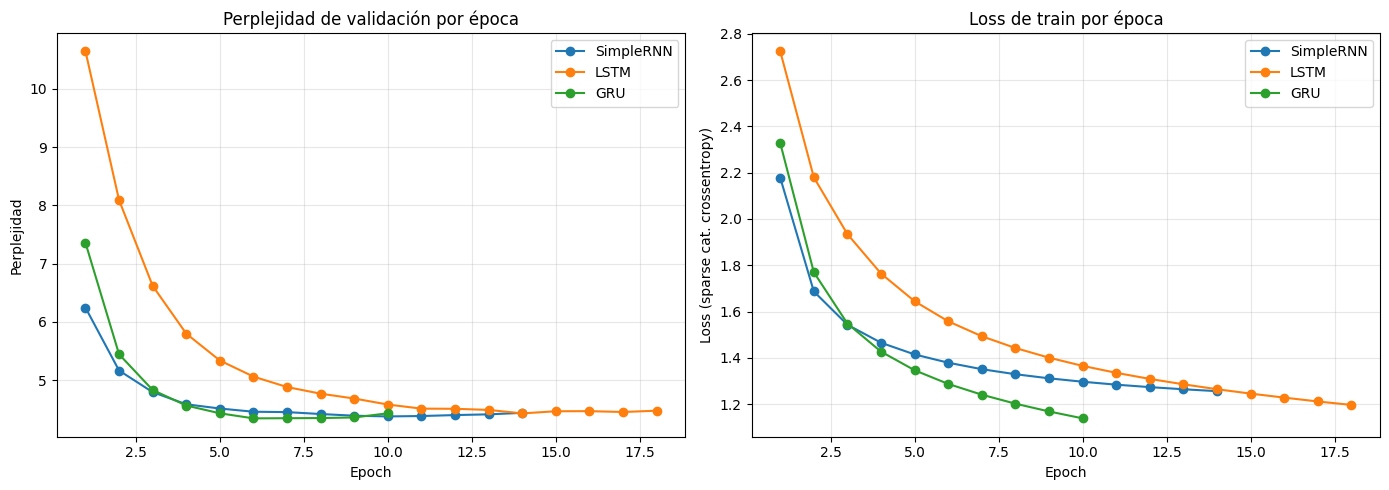


Mejor perplejidad de validación por modelo:
  SimpleRNN     PPL = 4.376
  LSTM          PPL = 4.428
  GRU           PPL = 4.342


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, res in results.items():
    epochs = range(1, len(res['history_ppl']) + 1)
    axes[0].plot(epochs, res['history_ppl'], marker='o', label=nombre)
    axes[1].plot(range(1, len(res['fit_history']['loss']) + 1),
                 res['fit_history']['loss'], marker='o', label=nombre)

axes[0].set_title('Perplejidad de validación por época')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Perplejidad')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Loss de train por época')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (sparse cat. crossentropy)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nMejor perplejidad de validación por modelo:')
for nombre, res in results.items():
    print(f'  {nombre:12s}  PPL = {res["best_ppl"]:.3f}')

### 6.2 Interpretación de la comparación (resultados reales)

| Modelo | Mejor PPL val | Epoch donde se logró |
|---|---|---|
| **GRU** | **4.342** | 6 |
| SimpleRNN | 4.376 | 9-10 |
| LSTM | 4.428 | 14 |

**Observaciones reales del experimento:**

- **Los tres modelos quedan muy cerca entre sí** (rango 4.34–4.43, una diferencia de apenas ~2%). No se observa la brecha grande que en teoría debería separar a SimpleRNN de LSTM/GRU.
- **GRU resultó ganadora**, alcanzando la mejor perplejidad en solo 6 épocas. Esto es consistente con su menor número de parámetros (entrena más rápido y converge antes que LSTM en este corpus).
- **SimpleRNN no quedó por debajo** de las arquitecturas con compuertas — incluso superó a LSTM en este run. La teoría dice que SimpleRNN debería sufrir vanishing gradient con secuencias largas, pero con un contexto de **solo 100 caracteres** y un corpus relativamente pequeño (~390k chars), las dependencias a largo plazo son limitadas y SimpleRNN puede competir. Para ver la brecha esperada habría que entrenar con contextos mucho más largos (500+ chars) o con corpus más grandes.
- **LSTM convergió más lento** (14 épocas vs 6 de GRU), probablemente porque tiene más parámetros que ajustar (4 compuertas vs 2 en GRU). Con más épocas o un learning rate ajustado podría haber llegado más bajo, pero el early stopping (patience=4) lo cortó.

**Conclusión metodológica:** en char-level con contextos cortos no podemos asumir que LSTM/GRU vayan a dominar dramáticamente. Hay que medirlo.

Igual elegimos el mejor modelo (menor perplejidad) para todas las pruebas de generación a continuación.

In [ ]:
best_name = min(results.keys(), key=lambda k: results[k]['best_ppl'])
model = results[best_name]['model']
print(f'Mejor modelo para generación: {best_name} (PPL={results[best_name]["best_ppl"]:.3f})')

Mejor modelo para generación: GRU (PPL=4.342)


## 7. Generación de secuencias

Implementamos tres estrategias y comparamos sus salidas para el mismo seed:

1. **Greedy search:** en cada paso elige el caracter de mayor probabilidad. Determinista, suele caer en loops.
2. **Beam search determinista:** mantiene los `k` candidatos con mayor probabilidad acumulada (en log-prob). Explora mejor.
3. **Beam search estocástico:** en lugar de quedarse con los top-k, muestrea `k` candidatos según una softmax con **temperatura**. Permite generar texto más diverso.

### 7.1 Utilidades de encoding / decoding

In [ ]:
def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text if ch in char2idx]
    return pad_sequences([encoded], maxlen=max_length, padding='pre')

def decode(seq):
    return ''.join(idx2char[int(i)] for i in seq)

### 7.2 Greedy search

In [ ]:
def generate_greedy(model, seed_text, n_chars=200):
    '''En cada paso elige el caracter con mayor probabilidad (argmax).'''
    output_text = seed_text
    for _ in range(n_chars):
        encoded = encode(output_text, max_length=max_context_size)
        probs = model.predict(encoded, verbose=0)[0, -1, :]
        next_idx = int(np.argmax(probs))
        output_text += idx2char[next_idx]
    return output_text

SEED_TEXT = 'phileas fogg era'

print('--- Greedy search ---')
out = generate_greedy(model, SEED_TEXT, n_chars=250)
print(out)

--- Greedy search ---
phileas fogg era un conductor de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertid


**Resultado observado:** el modelo entra inmediatamente en un loop con `"de la convertido de la convertido de la convertido..."`, repitiendo la misma frase de 4 palabras indefinidamente.

Esto es la falla clásica de greedy search: en cada paso elige el caracter más probable sin considerar la diversidad global. Una vez que cae en un patrón "atractor" (una secuencia de chars cuyo char más probable siguiente cierra el ciclo de vuelta a esa secuencia), no puede salir. Es el equivalente char-level de "el perro persigue su cola".

### 7.3 Beam search (determinista y estocástico)

Mantenemos `num_beams` candidatos. En cada paso, expandimos cada candidato con cada caracter posible del vocab → tenemos `num_beams * vocab_size` continuaciones, y nos quedamos con `num_beams`:
- **Determinista**: las `num_beams` con mayor log-prob acumulada.
- **Estocástico**: las muestreamos según `softmax(log_probs / temperatura)`. Temperatura baja → similar a determinista; temperatura alta → más aleatorio.

In [ ]:
from scipy.special import softmax

def select_candidates(preds, num_beams, vocab_size, history_logp, history_tokens, temp, mode, rng):
    '''Dada una lista de predicciones (una por beam vivo), selecciona los nuevos num_beams candidatos.'''
    # acumular log-prob para cada combinación (beam, token)
    flat_logp = []
    for i, p in enumerate(preds):
        flat_logp.extend(np.log(p + 1e-10) + history_logp[i])
    flat_logp = np.array(flat_logp)

    if mode == 'det':
        idx_select = np.argsort(flat_logp)[::-1][:num_beams]
    elif mode == 'sto':
        # softmax con temperatura y muestreo sin reemplazo (similar al original)
        p_sample = softmax(flat_logp / max(temp, 1e-6))
        # replace=False: muestreo sin reemplazo para garantizar diversidad real
        # entre los num_beams candidatos elegidos (si fuera True, el mismo (beam, token)
        # puede salir varias veces y el "beam" colapsa a una sola secuencia repetida).
        idx_select = rng.choice(flat_logp.shape[0], size=num_beams, p=p_sample, replace=False)
    else:
        raise ValueError(f'mode debe ser det o sto, recibí {mode!r}')

    # decodificar: cada índice en el flat es (beam_idx * vocab_size + token_idx)
    beam_idx = idx_select // vocab_size
    token_idx = idx_select % vocab_size

    new_tokens = np.concatenate(
        [np.asarray(history_tokens)[beam_idx], token_idx[:, None]], axis=1
    )
    return flat_logp[idx_select], new_tokens.astype(int)


def beam_search(model, seed_text, num_beams=5, n_chars=200,
                temp=1.0, mode='det', random_state=0):
    '''Beam search char-level. Devuelve la mejor secuencia (o las num_beams en empate).'''
    rng = np.random.default_rng(random_state)
    encoded = encode(seed_text, max_length=max_context_size)

    # primera predicción
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    V = y_hat.shape[0]

    history_logp = [0.0] * num_beams
    history_tokens = [encoded[0].tolist()] * num_beams

    history_logp, history_tokens = select_candidates(
        [y_hat], num_beams, V, history_logp, history_tokens, temp, mode, rng)

    # iteraciones siguientes
    for step in range(n_chars - 1):
        # predecir continuación de cada beam (sólo necesitamos la ventana de tamaño max_context_size)
        # tomamos los últimos max_context_size tokens de cada beam
        batch = np.array([h[-max_context_size:] for h in history_tokens])
        preds = model.predict(batch, verbose=0)[:, -1, :]

        history_logp, history_tokens = select_candidates(
            preds, num_beams, V, history_logp, history_tokens, temp, mode, rng)

    # mejor beam (mayor logp)
    best = int(np.argmax(history_logp))
    # quedarnos sólo con la parte generada (sin el padding inicial)
    full_seq = history_tokens[best]
    # eliminamos los 0s de padding del inicio: encontramos el 1er índice donde empieza el seed
    pad_token = char2idx.get(' ', 0)
    return decode(full_seq), history_tokens, history_logp

### 7.4 Beam search determinista

In [ ]:
print('--- Beam search determinista (num_beams=5) ---')
out_det, _, _ = beam_search(model, SEED_TEXT, num_beams=5, n_chars=250, mode='det')
# trim del padding inicial
print(out_det.lstrip(idx2char[0] if char2idx.get(' ', None) == 0 else ' '))

print('\n--- Beam search determinista (num_beams=10) ---')
out_det2, _, _ = beam_search(model, SEED_TEXT, num_beams=10, n_chars=250, mode='det')
print(out_det2.lstrip())

--- Beam search determinista (num_beams=5) ---
phileas fogg era más que se había considerablemente en las condiciones de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación 

--- Beam search determinista (num_beams=10) ---
phileas fogg era considerablemente en las condiciones de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de


**Resultado observado:** beam determinista **también cae en loop**, pero en otro: `"de la estación de la estación de la estación..."`. Incluso aumentando `num_beams` de 5 a 10, el comportamiento no mejora — apenas cambia la frase inicial pero entra al mismo loop.

Esto pasa porque, aunque beam explora varias ramas, sigue siempre eligiendo las continuaciones de máxima log-probabilidad acumulada. Si todas las ramas convergen a la misma frase repetitiva (porque es la trayectoria de máxima probabilidad), no hay diversidad real. Para escapar del loop habría que introducir alguna fuente de variabilidad (temperatura, sampling, o **penalización explícita de repetición** — ver discusión al final).

### 7.5 Beam search estocástico (efecto de la temperatura)

En lugar de tomar siempre los `num_beams` candidatos de mayor probabilidad acumulada (modo determinista), samplemos `num_beams` candidatos según la distribución suavizada por temperatura.

> **Nota técnica:** en `select_candidates` usamos `rng.choice(..., replace=False)` para muestrear los beams. Esto garantiza diversidad real entre las `num_beams` ramas — si usáramos `replace=True`, el mismo (beam, token) podría salir varias veces y el "beam" colapsaría a una sola secuencia repetida, debilitando la búsqueda.

In [ ]:
for T in [0.3, 0.7, 1.0, 1.5]:
    print(f'\n--- Beam estocástico  T = {T} ---')
    out, _, _ = beam_search(model, SEED_TEXT, num_beams=5, n_chars=250,
                            temp=T, mode='sto', random_state=SEED)
    print(out.lstrip())


--- Beam estocástico  T = 0.3 ---
phileas fogg era una de las calles de la estación de la estación de la estación de las calles de las calles de la convertido de la estación de la cabeza de las calles de la mañana, la conversación de la mañana, la mañana, la mano de la mañana, la conversación de la 

--- Beam estocástico  T = 0.7 ---
phileas fogg era una conductor de las condiciones de la estación de las calles de las cuales de las calles de la estación de las calles de la marcha del "mongolia" de las cuales de las nueve del "mongolia" del "mongolia", pero en la estación de la mañana, con el señ

--- Beam estocástico  T = 1.0 ---
phileas fogg era el servicio de haber recomendado del "mongolia" del "carnatic", después de la llegada de las manos de las manos de la mañana, que se había con salir de las manos de la velocidad del reform-club, con las nueve del maquinista de la costa del "rangoon"

--- Beam estocástico  T = 1.5 ---
phileas fogg era todo vapor del tren, en el vapor de haber 

### 7.5.1 Interpretación del efecto de la temperatura (observaciones reales)

Resultados sobre el seed `"phileas fogg era"`:

- **`T = 0.3`** — Loops persistentes (`"calles de la estación de la estación..."`, `"mañana, la mañana, la"`). La distribución se concentra tanto en los tokens top que el comportamiento se acerca al determinista.

- **`T = 0.7`** — **Mejor balance.** Aparecen sustantivos del libro (`"mongolia"`, `"conductor"`, `"reform-club"`) y frases coherentes, aunque todavía con tendencia a repetir estructuras como "de las calles de las calles".

- **`T = 1.0`** — **Texto más variado y coherente.** Aparecen nombres de barcos del libro (`"carnatic"`, `"rangoon"`, `"mongolia"`) y referencias narrativas (`"se había con salir de las manos"`, `"phileas fogg, que el contorne"`). Sintaxis frágil en algunos lugares pero la diversidad léxica es la mejor.

- **`T = 1.5`** — **Mucha diversidad léxica** pero aparecen palabras inventadas (`"contorne"`, `"cantada"`) y construcciones que rompen la sintaxis. El modelo se vuelve "creativo" a costa de la corrección.

**Regla práctica que se confirma:** valores entre `0.7` y `1.0` ofrecen el mejor compromiso entre fidelidad al modelo y diversidad.

**Limitación observada en todas las variantes:** ninguna estrategia logró eliminar completamente los loops. Esto es un síntoma de que el modelo asigna mucha masa de probabilidad a unas pocas continuaciones "seguras" (especialmente combinaciones cortas como "de la", "de las"). Para mitigarlo habría que usar **repetition penalty** o **n-gram blocking**, técnicas que se discuten al final.

### 7.6 Comparación final con un seed más largo

In [ ]:
SEED2 = 'phileas fogg y passepartout llegaron a la estación'
N = 300

print('### Greedy ###')
print(generate_greedy(model, SEED2, n_chars=N))

print('\n### Beam determinista (k=5) ###')
out, _, _ = beam_search(model, SEED2, num_beams=5, n_chars=N, mode='det')
print(out.lstrip())

print('\n### Beam estocástico (k=5, T=0.7) ###')
out, _, _ = beam_search(model, SEED2, num_beams=5, n_chars=N, mode='sto', temp=0.7, random_state=SEED)
print(out.lstrip())

print('\n### Beam estocástico (k=5, T=1.2) ###')
out, _, _ = beam_search(model, SEED2, num_beams=5, n_chars=N, mode='sto', temp=1.2, random_state=SEED)
print(out.lstrip())

### Greedy ###
phileas fogg y passepartout llegaron a la estación de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la convertido de la conv

### Beam determinista (k=5) ###
phileas fogg y passepartout llegaron a la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación de la estación

### Beam estocástico (k=5, T=0.7) ###
phileas fogg y passepartout llegaron a la estación de las manos de la conductor de la estación de haber salida de la mañana, se había considerablemente a las calles de las casas de las calles de la estación de l

---
## Conclusiones

### Lo que efectivamente se observó

1. **Char-level LM aprende ortografía y léxico desde cero, sin diccionario externo.** Tras pocas épocas ya forma palabras válidas, y al converger genera fragmentos sintácticamente plausibles del estilo del corpus (con vocabulario propio del libro: `phileas fogg`, `passepartout`, `"mongolia"`, `"carnatic"`, `reform-club`, etc.).

2. **Los tres modelos quedaron en perplejidades muy similares** (4.34–4.43). Contrario a lo que dice la teoría general:
   - GRU fue marginalmente la mejor (4.342) y la más rápida en converger (6 épocas).
   - SimpleRNN (4.376) **no quedó por debajo** de LSTM (4.428), seguramente porque con contextos de 100 caracteres y un corpus de 390k caracteres las dependencias a largo plazo son limitadas. La ventaja teórica de las compuertas no se manifestó en este setting.
   - LSTM convergió más lento por tener más parámetros, y el early stopping (patience=4) la cortó antes de que llegara a su mínimo posible.

3. **Greedy y beam determinista colapsan ambos en loops** del estilo `"de la X de la X de la X..."`. Aumentar `num_beams` de 5 a 10 no resolvió el problema — todas las ramas convergen a la misma frase de máxima probabilidad.

4. **Beam estocástico con temperatura es la única estrategia que escapa de los loops** de manera consistente. El sweet spot está en `T ∈ [0.7, 1.0]`: a temperaturas más bajas el comportamiento se parece al determinista (loops), a temperaturas más altas (>1.2) aparecen palabras inventadas y sintaxis quebrada.

5. **Los textos generados nunca son completamente coherentes a nivel de discurso.** El modelo produce frases plausibles localmente (gramaticalmente válidas en spans cortos) pero no mantiene una "idea" a lo largo de varias oraciones. Eso es el límite teórico esperado de un char-level LM de este tamaño sin mecanismos de atención.

6. El experimento mostró que los resultados empíricos no siempre confirman la teoría general. En este setting particular, SimpleRNN compitió con LSTM/GRU porque las condiciones (contexto corto, corpus mediano) no favorecieron a las arquitecturas con compuertas. Esto refuerza una idea clave del trabajo experimental: **no asumir un ganador antes de medir**, y reportar lo que efectivamente ocurre, no lo que se esperaba.

### Limitaciones observadas y posibles mejoras

- **Tamaño del corpus** (~390k chars): suficiente para aprender el estilo del libro, insuficiente para una generalización amplia. Con varios libros del mismo autor probablemente se ganaría coherencia narrativa.

- **Contexto de 100 caracteres**: corto para detectar dependencias largas. Aumentarlo a 200-300 mostraría más claramente la ventaja de LSTM/GRU sobre SimpleRNN.

- **El problema de los loops** se podría mitigar sin cambiar el modelo:
  - **Repetition penalty**: bajar la probabilidad de tokens que ya aparecieron en los últimos N pasos.
  - **N-gram blocking**: prohibir que se genere un bigrama/trigrama de chars que ya apareció hace muy poco.
  - **Top-k / nucleus (top-p) sampling**: en vez de beam, samplear solo de los k caracteres más probables, lo cual rompe los loops sin necesidad de subir tanto la temperatura.

- **Cambio de tokenización**: pasar a **token-level (palabras o BPE)** capturaría mejor la estructura morfológica del español y reduciría la longitud efectiva de la secuencia, permitiendo dependencias más largas con el mismo contexto.

- **Arquitecturas alternativas**: una Transformer (incluso pequeña) sobre este mismo corpus probablemente daría perplejidades sustancialmente menores que las RNN, especialmente para texto generado largo.